In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit
from Analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit


In [24]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)

In [25]:
import sklearn
from sklearn.decomposition import PCA

In [27]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [28]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

In [29]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_env_ene(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        # q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        # q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)):
                t = t
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

Fogi timing

In [30]:
header = "D:/K_sunada/result/CDY167/"

In [31]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_timing(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_delay = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        d = dd['fogi_delay']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_ref']['values'][k:k+num_of_fogi_freq]
        # q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_delay.append(d)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        # q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_delay[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)):
                t = t
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_delay, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

photon freq = 9.35

In [32]:
ph0_fo0 = "/2024-10-04/2024-10-04T191010_d6c8ae79-75-sym_JPA_ab_fogi_timing"
ph0_fo1 = "/2024-10-04/2024-10-04T203155_42503e75-75-sym_JPA_ab_fogi_timing"
ph0_fo2 = "/2024-10-04/2024-10-04T215345_b0f5eb0a-75-sym_JPA_ab_fogi_timing"
ph0_fo3 = "/2024-10-04/2024-10-04T231547_26ccf977-75-sym_JPA_ab_fogi_timing"

In [33]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time00 = d[0][ph_amp]
ph0fo0 = d[5][ph_amp]

In [38]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time01 = d[0][ph_amp]
ph0fo1 = d[5][ph_amp]

In [39]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo2
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time02 = d[0][ph_amp]
ph0fo2 = d[5][ph_amp]

In [40]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo3
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time03 = d[0][ph_amp]
ph0fo3 = d[5][ph_amp]

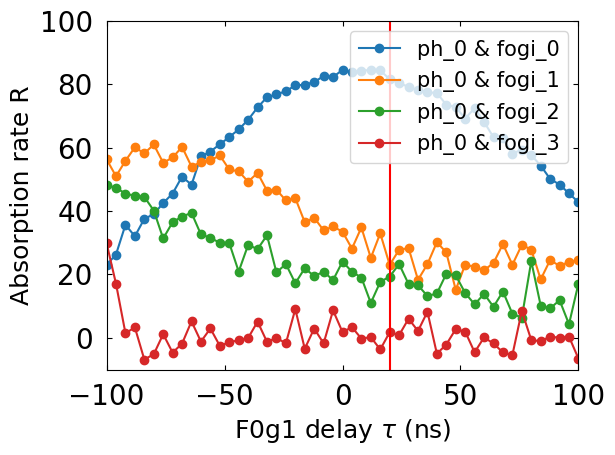

In [45]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time00, ph0fo0, "o-", label= "ph_0 & fogi_0")
plt.plot(time01, ph0fo1, "o-", label= "ph_0 & fogi_1")
plt.plot(time02, ph0fo2, "o-", label= "ph_0 & fogi_2")
plt.plot(time03, ph0fo3, "o-", label= "ph_0 & fogi_3")
plt.vlines(20, -10, 100, color="r")
plt.legend()
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_13700\116999306.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


83.76


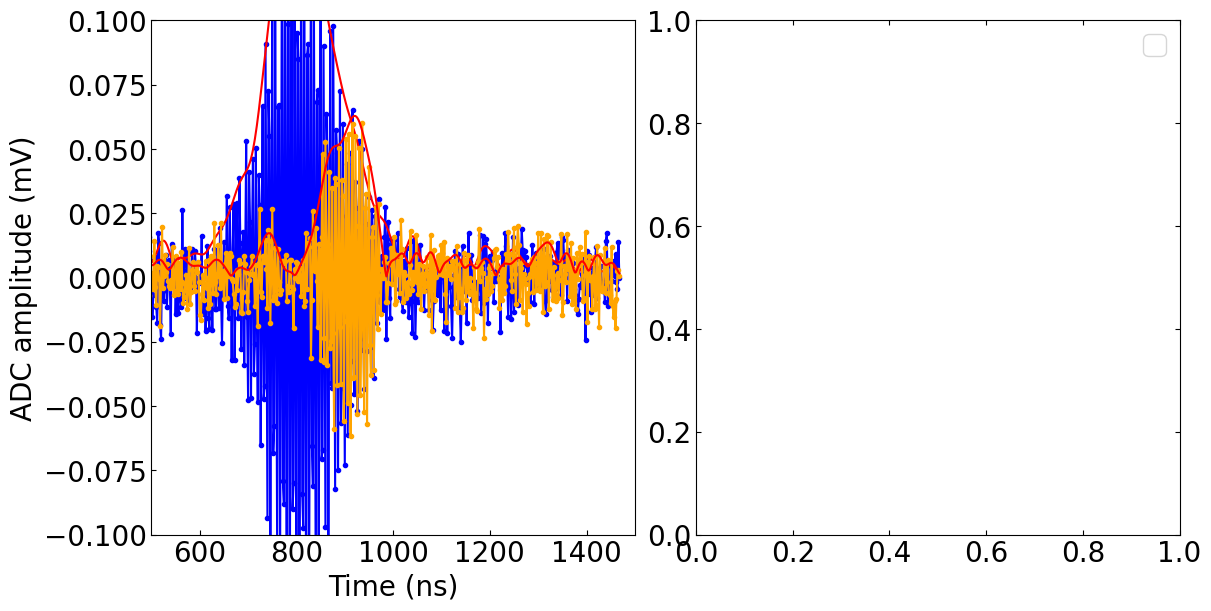

In [44]:
## waveform
ph_amp = 0
fogi_freq = 26
###############################################
data = ph0_fo0
num_of_ph_amp = 1
num_of_fogi_freq = 51
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_freq, (9.5-9.35)*1e9)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

# fogi_freq1 = 30
# ###############################################
# data1 = ph1_fo0
# num_of_fogi_freq1 = 76
# ###############################################
# d1 = data_acquisition_timing(header, data1,num_of_ph_amp, num_of_fogi_freq1, (9.47-9.35)*1e9)
# freq1 = d1[0][ph_amp][fogi_freq1]
# energy1 = d1[4][ph_amp][fogi_freq1]
# ab_rate1 = d1[5][ph_amp][fogi_freq1]

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[8][ph_amp][fogi_freq])*1e3, color='red')
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[7][ph_amp][fogi_freq])*1e3, color='red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.1, 0.1)
ax[0].set_xlim(500, 1500)

# ax[1].set_xlabel('Time (ns)')
# ax[1].set_ylabel(r'ADC amplitude (mV)')
# ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[3][ph_amp][fogi_freq1])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
# ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[8][ph_amp][fogi_freq1])*1e3, color='red')
# ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[2][ph_amp][fogi_freq1])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
# ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[7][ph_amp][fogi_freq1])*1e3, color='red')
# ax[1].tick_params(axis="x", direction="in")
# ax[1].tick_params(axis="y", direction="in")
# ax[1].set_ylim(-0.1, 0.1)
# ax[1].set_xlim(500, 1500)
plt.legend()
print(np.round(ab_rate, 2))
# print(np.round(ab_rate1, 2))
plt.show()

84.53
-9.15


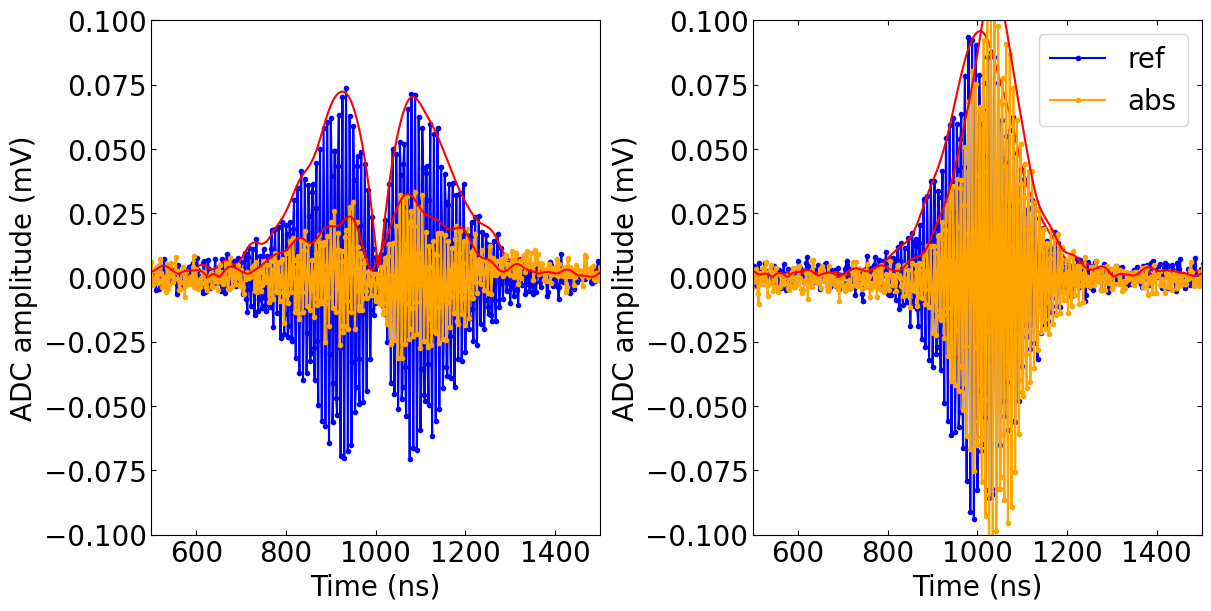

In [89]:
## waveform
ph_amp = 0
fogi_freq = 30
###############################################
data = ph1_fo1
num_of_ph_amp = 1
num_of_fogi_freq = 76
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_freq, (9.47-9.35)*1e9)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fogi_freq1 = 30
###############################################
data1 = ph0_fo1
num_of_fogi_freq1 = 76
###############################################
d1 = data_acquisition_timing(header, data1,num_of_ph_amp, num_of_fogi_freq1, (9.47-9.35)*1e9)
freq1 = d1[0][ph_amp][fogi_freq1]
energy1 = d1[4][ph_amp][fogi_freq1]
ab_rate1 = d1[5][ph_amp][fogi_freq1]

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[8][ph_amp][fogi_freq])*1e3, color='red')
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[7][ph_amp][fogi_freq])*1e3, color='red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.1, 0.1)
ax[0].set_xlim(500, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[3][ph_amp][fogi_freq1])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[8][ph_amp][fogi_freq1])*1e3, color='red')
ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[2][ph_amp][fogi_freq1])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[7][ph_amp][fogi_freq1])*1e3, color='red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_ylim(-0.1, 0.1)
ax[1].set_xlim(500, 1500)
plt.legend()
print(np.round(ab_rate, 2))
print(np.round(ab_rate1, 2))
plt.show()

In [90]:
def fit_waveform(time, data, x0=[2e-3,600], get_center=False, curve='gaussian', **kwargs):
    if curve=='gaussian':
        func = lambda x: x[0]*np.exp(-((time-x[1])/kwargs['sigma'])**2/2)
        cost_func = lambda x: np.linalg.norm(x[0]*np.exp(-((time-x[1])/kwargs['sigma'])**2/2) - data)
    elif curve=='sech':
        func = lambda x: x[0]/np.cosh(kwargs['kappa']*(time-x[1]))
        cost_func = lambda x: np.linalg.norm(x[0]/np.cosh(kwargs['kappa']*(time-x[1])) - data)
    elif curve=="raisedcos":
        func = lambda x: x[0]*np.sin(np.pi*(time-x[1])/kwargs['T'])**2*(time<=kwargs['T']+x[1])*(x[1]<=time)
        cost_func = lambda x: np.linalg.norm(x[0]*np.sin(np.pi*(time-x[1])/kwargs['T'])**2*(time<=kwargs['T']+x[1])*(x[1]<=time) - data)
    elif curve=="anti_sech":
        func = lambda x: np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    best_x = optimize.minimize(cost_func, x0=x0,method='Nelder-Mead',)
    # print(best_x)
    # print(f"center:{best_x.x}")
    if get_center==True:
        return best_x.x, func(best_x.x)
    return func(best_x.x)

def IQ_sym_(wave,time,start=0,stop=3000):
    wave_rev = np.flip(wave).conj()
    norm=np.sum(np.abs(wave)**2)**2
    m=0
    c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = wave*wave_rev_i
        mult_sum=np.sum(mult)
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    # plt.plot(np.arange(len(wave)), c)
    return m/norm

def target_overlap(wave, time, curve='sech'):
    wave = np.abs(wave) ### changed by Sunada
    wave_rev = np.flip(wave)
    if curve=='sech':
        target = 1 / np.cosh(const * (time-time[-1]/2))
    elif curve=="anti_sech":
        target = np.abs((time-time[-1]/2) / np.cosh(const * (time-time[-1]/2)))
    target = np.abs(target)
    norm = np.sum(np.abs(wave)**2) * (time[1] - time[0])
    norm_target  =np.sum(np.abs(target)**2) * (time[1] - time[0])
    m=0 ;c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = target*wave_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    return m / norm / norm_target

In [91]:
from scipy import interpolate, optimize

Waveform analysis after absorrption

symmetry 0.8152266035433706, overlap 0.9438699893162121


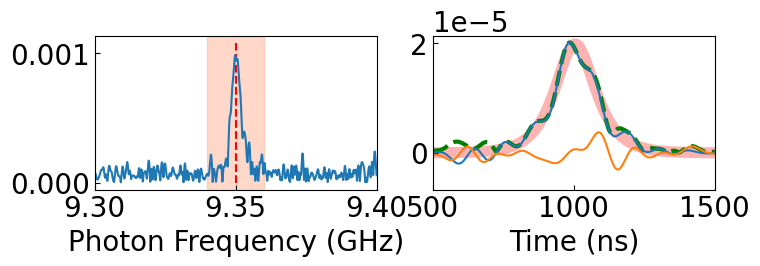

In [92]:
fig = plt.figure(figsize=(8, 2))
ax = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
passing_band = 0.01
target_freq = 9.35
duration = 1500
readout_lo_freq = 9.47
const = 2.5e-3 * 2 * np.pi
datadict = datadict_from_hdf5(header + ph0_fo0 +"/data")

id = 55
time = datadict["time"]["values"][id].ravel()
waveform = datadict["waveform"]["values"][id].ravel()
time, waveform = start_stop(time, waveform, 0, duration)
phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
# print(readout_lo_freq-target_freq)
xfft, fourier = fourier_tr_padding(time, waveform)
xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
photon_freq = readout_lo_freq + xfft
ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
ax.plot(photon_freq, np.abs(fourier))
ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
ax.set_xlim(9.3, 9.4)
ax.set_xlabel("Photon Frequency (GHz)")

signal = 2 * lowpass(time, 
                    waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                    passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
ax2.plot(time, signal.real, label="real")
ax2.plot(time, signal.imag, label="imag")
ax2.set_xlabel("Time (ns)")
ax2.set_xlim(500, 1500)
print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech')}")
# plt.legend()


symmetry 0.7759637316295648, overlap 0.6971950008087114


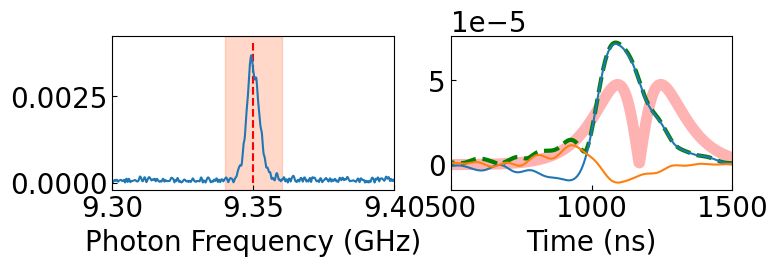

In [93]:
fig = plt.figure(figsize=(8, 2))
ax = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
passing_band = 0.01
target_freq = 9.35
duration = 1500
readout_lo_freq = 9.47
const = 2.5e-3 * 2 * np.pi
datadict = datadict_from_hdf5(header + ph1_fo0 +"/data")

id = 30
time = datadict["time"]["values"][id].ravel()
waveform = datadict["waveform"]["values"][id].ravel()
time, waveform = start_stop(time, waveform, 0, duration)
phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
# print(readout_lo_freq-target_freq)
xfft, fourier = fourier_tr_padding(time, waveform)
xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
photon_freq = readout_lo_freq + xfft
ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
ax.plot(photon_freq, np.abs(fourier))
ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
ax.set_xlim(9.3, 9.4)
ax.set_xlabel("Photon Frequency (GHz)")

signal = 2 * lowpass(time, 
                    waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                    passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
res = fit_waveform(time, np.abs(signal), curve="anti_sech", kappa=const)
ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
ax2.plot(time, signal.real, label="real")
ax2.plot(time, signal.imag, label="imag")
ax2.set_xlabel("Time (ns)")
ax2.set_xlim(500, 1500)
print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='anti_sech')}")
# plt.legend()


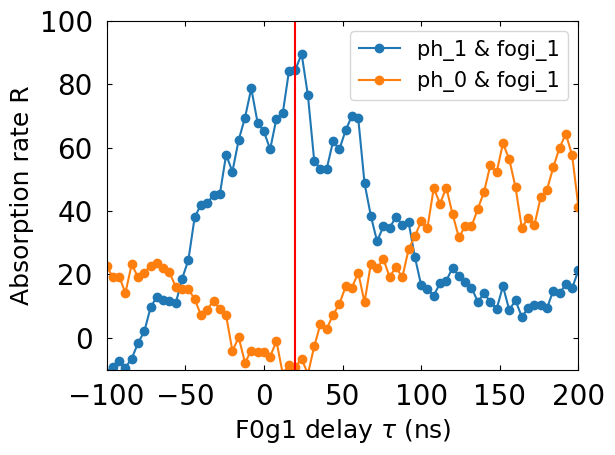

In [94]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 200)
plt.tight_layout()
plt.plot(time11, ph1fo1, "o-", label= "ph_1 & fogi_1")
plt.plot(time01, ph0fo1, "o-", label= "ph_0 & fogi_1")
plt.vlines(20, -10, 100, color="r")
plt.legend()
plt.show()

symmetry 0.8449757364838794, overlap 0.9510924814750473


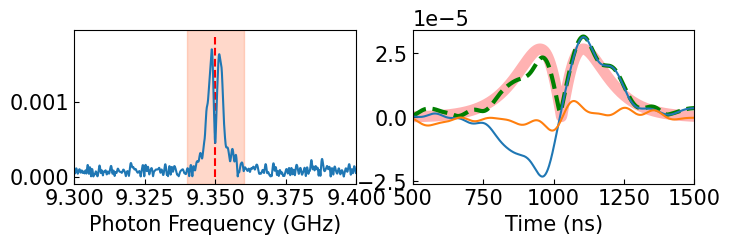

In [95]:
fig = plt.figure(figsize=(8, 2))
ax = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
passing_band = 0.01
target_freq = 9.35
duration = 1500
readout_lo_freq = 9.47
const = 2.5e-3 * 2 * np.pi
datadict = datadict_from_hdf5(header + ph1_fo1 +"/data")

id = 30
time = datadict["time"]["values"][id].ravel()
waveform = datadict["waveform"]["values"][id].ravel()
time, waveform = start_stop(time, waveform, 0, duration)
phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
# print(readout_lo_freq-target_freq)
xfft, fourier = fourier_tr_padding(time, waveform)
xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
photon_freq = readout_lo_freq + xfft
ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
ax.plot(photon_freq, np.abs(fourier))
ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
ax.set_xlim(9.3, 9.4)
ax.set_xlabel("Photon Frequency (GHz)")

signal = 2 * lowpass(time, 
                    waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                    passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
res = fit_waveform(time, np.abs(signal), curve="anti_sech", kappa=const)
ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
ax2.plot(time, signal.real, label="real")
ax2.plot(time, signal.imag, label="imag")
ax2.set_xlabel("Time (ns)")
ax2.set_xlim(500, 1500)
print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='anti_sech')}")
# plt.legend()


symmetry 0.9471672752369501, overlap 0.9829149644511068


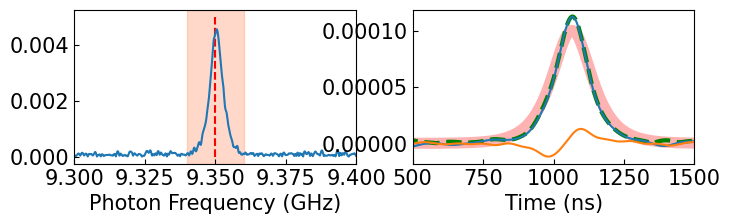

In [96]:
fig = plt.figure(figsize=(8, 2))
ax = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
passing_band = 0.01
target_freq = 9.35
duration = 1500
readout_lo_freq = 9.47
const = 2.5e-3 * 2 * np.pi
datadict = datadict_from_hdf5(header + ph0_fo1 +"/data")

id = 30
time = datadict["time"]["values"][id].ravel()
waveform = datadict["waveform"]["values"][id].ravel()
time, waveform = start_stop(time, waveform, 0, duration)
phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
# print(readout_lo_freq-target_freq)
xfft, fourier = fourier_tr_padding(time, waveform)
xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
photon_freq = readout_lo_freq + xfft
ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
ax.plot(photon_freq, np.abs(fourier))
ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
ax.set_xlim(9.3, 9.4)
ax.set_xlabel("Photon Frequency (GHz)")

signal = 2 * lowpass(time, 
                    waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                    passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
ax2.plot(time, signal.real, label="real")
ax2.plot(time, signal.imag, label="imag")
ax2.set_xlabel("Time (ns)")
ax2.set_xlim(500, 1500)
print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech')}")
# plt.legend()


photon0 + photon1

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit
from Analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit


In [98]:
ph01_fo0 = "/2024-08-02/2024-08-02T102927_a875c953-75-sym_JPA_ab_fogi_timing"
ph01_fo1 = "/2024-08-01/2024-08-01T231647_b012d9c8-75-sym_JPA_ab_fogi_timing_oth"

[-14.93594451 -13.05643384 -12.19804782 -11.65105054 -12.71579523
 -10.09848706  -3.49313842  -3.56665543   4.51816617  -0.74665895
   2.79033392   2.50749539   5.58403845   9.61014714   7.16416288
   9.89875011  11.8846525   13.80209309  21.81842002  20.59012265
  26.25268045  25.80787457  26.20386258  32.42577917  37.02312047
  35.82503438  36.5534455   41.29913667  44.59830109  49.54339841
  50.52003685  55.64285917  54.88898056  60.47925607  62.9125374
  63.70037164  60.87925113  62.96670696  68.70501341  73.32506845
  74.32722474  74.92696615  72.79082798  74.72053271  75.65170862
  76.70941431  77.09313551  76.81974196  78.94706083  75.48617415
  78.385676    70.82694761  64.95814413  62.29077873  68.59499024
  75.27069735  73.40270481  66.38729646  64.23341214  66.43742744
  71.25879986  74.22534897  71.03919318  71.22557969  71.81325847
  71.52789626  69.00177475  68.63794357  64.95450228  64.20499345
  61.03815399  61.55924568  65.7222646   62.8773547   59.34510811
  53.187531

<Figure size 800x600 with 0 Axes>

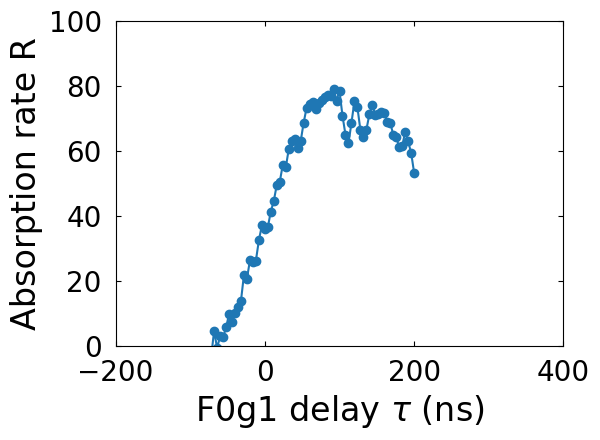

In [103]:
## absorption rate
ph_amp = 0
###############################################
data = ph01_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 76
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(0, 100)
ax1.set_xlim(-200, 400)
print(d[5][ph_amp])
plt.tight_layout()
plt.show()
time00 = d[0][ph_amp]
ph0fo0 = d[5][ph_amp]

[11.19266329  6.25645433  4.9110752  17.67583957 18.07344352 20.75556618
 26.98086586 27.51237899 31.23825062 35.35750959 37.74914172 39.63909139
 40.39302028 41.35290207 44.86538084 45.08489072 42.91858795 47.27094883
 33.76675621 31.58539369 31.99530055 37.64072944 34.84833403 36.99098698
 26.00948165 24.25315744 22.15594528 22.23823814 16.18014198 14.14123614
  9.76425936 14.31092497 10.71060236  8.02723087 -1.23548208  4.56203755
 -1.25550837  1.66270669 -1.73579652 -2.38294494  2.44018427 -3.99121051
 -6.04245034 -2.7261456   4.8202994   2.60752423  4.00175211  2.7265766
  6.16734168  3.10259371 13.601998   14.02767345 11.60557557 12.9081416
 12.21239102 13.31829819 18.16869333 19.24932236 19.19810108 20.40930155
 22.95177664 27.29614056 24.90387889 30.54083913 28.13156626 35.00166704
 31.85464357 37.57183396 34.08986308 42.2389885  37.50201752 40.88697802
 36.32371714 40.60914655 41.09873563 45.86745914]


<Figure size 800x600 with 0 Axes>

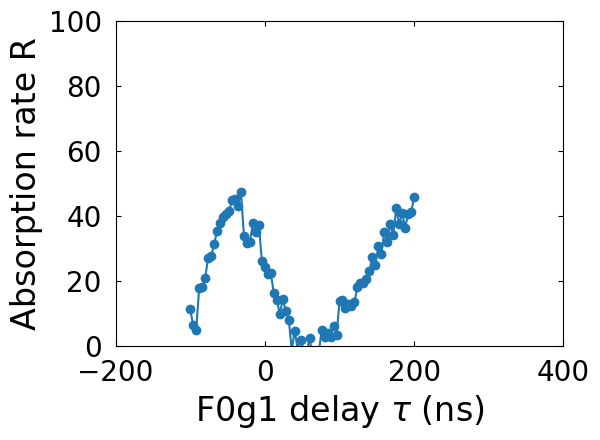

In [105]:
## absorption rate
ph_amp = 0
###############################################
data = ph01_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 76
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(0, 100)
ax1.set_xlim(-200, 400)
print(d[5][ph_amp])
plt.tight_layout()
plt.show()
time00 = d[0][ph_amp]
ph0fo0 = d[5][ph_amp]

50.52
9.76


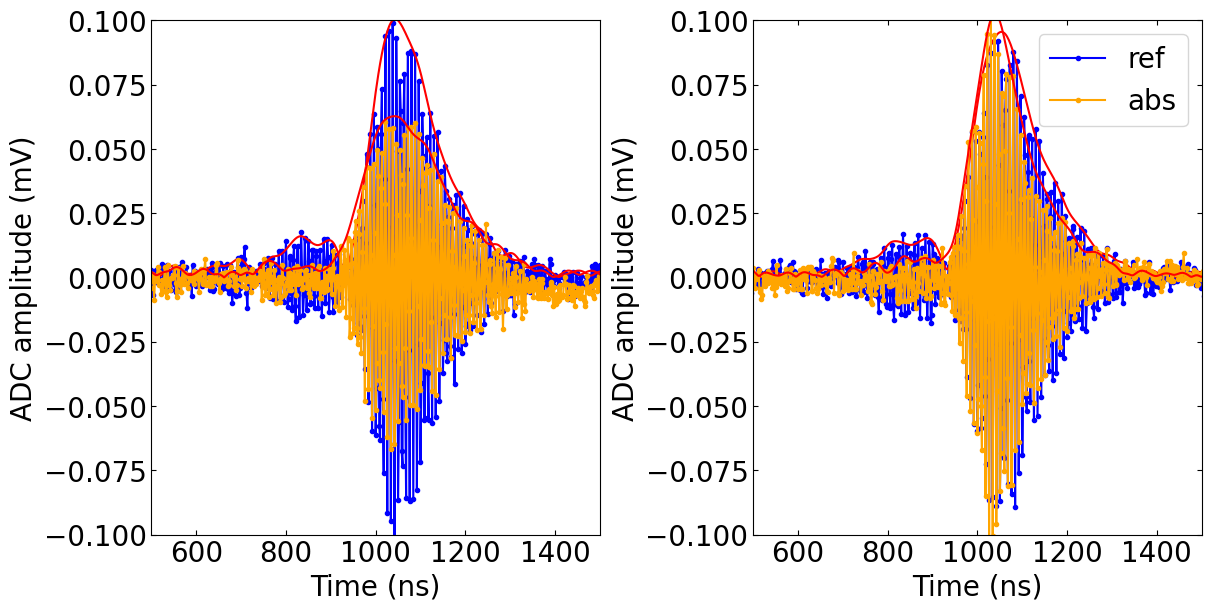

In [101]:
## waveform
ph_amp = 0
fogi_freq = 30
###############################################
data = ph01_fo0
num_of_ph_amp = 1
num_of_fogi_freq = 76
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_freq, (9.47-9.35)*1e9)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fogi_freq1 = 30
###############################################
data1 = ph01_fo1
num_of_fogi_freq1 = 76
###############################################
d1 = data_acquisition_timing(header, data1,num_of_ph_amp, num_of_fogi_freq1, (9.47-9.35)*1e9)
freq1 = d1[0][ph_amp][fogi_freq1]
energy1 = d1[4][ph_amp][fogi_freq1]
ab_rate1 = d1[5][ph_amp][fogi_freq1]

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[8][ph_amp][fogi_freq])*1e3, color='red')
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[0].plot(d[1][ph_amp][fogi_freq]-30,  (d[7][ph_amp][fogi_freq])*1e3, color='red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.1, 0.1)
ax[0].set_xlim(500, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[3][ph_amp][fogi_freq1])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[8][ph_amp][fogi_freq1])*1e3, color='red')
ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[2][ph_amp][fogi_freq1])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[1].plot(d1[1][ph_amp][fogi_freq1]-30,  (d1[7][ph_amp][fogi_freq1])*1e3, color='red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_ylim(-0.1, 0.1)
ax[1].set_xlim(500, 1500)
plt.legend()
print(np.round(ab_rate, 2))
print(np.round(ab_rate1, 2))
plt.show()

In [ ]:
fig = plt.figure(figsize=(8, 2))
ax = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
passing_band = 0.01
target_freq = 9.35
duration = 1500
readout_lo_freq = 9.47
const = 2.5e-3 * 2 * np.pi
datadict = datadict_from_hdf5(header + ph0_fo0 +"/data")

id = 55
time = datadict["time"]["values"][id].ravel()
waveform = datadict["waveform"]["values"][id].ravel()
time, waveform = start_stop(time, waveform, 0, duration)
phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
# print(readout_lo_freq-target_freq)
xfft, fourier = fourier_tr_padding(time, waveform)
xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
photon_freq = readout_lo_freq + xfft
ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
ax.plot(photon_freq, np.abs(fourier))
ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
ax.set_xlim(9.3, 9.4)
ax.set_xlabel("Photon Frequency (GHz)")

signal = 2 * lowpass(time, 
                    waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                    passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
ax2.plot(time, signal.real, label="real")
ax2.plot(time, signal.imag, label="imag")
ax2.set_xlabel("Time (ns)")
ax2.set_xlim(500, 1500)
print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech')}")
# plt.legend()


In [120]:
def waveforms_overlap(wave0, wave1, time):
    wave0 = np.abs(wave0)
    wave1 = np.abs(wave1)
    norm0 = np.sum(np.abs(wave0)**2) * (time[1] - time[0])
    norm1  =np.sum(np.abs(wave1)**2) * (time[1] - time[0])
    m=0 ;c=[]
    for i in range(len(wave1)):
        wave1_i = np.roll(wave1, i)
        mult = wave0*wave1_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        c.append(cand)
        if m<cand:
            m=cand
    return m / norm0 / norm1

## overwrap
photon0 - fogi1

photon01 - fogi1

In [124]:
id = 30
time = datadict["time"]["values"][id].ravel()
dd0 = datadict_from_hdf5(header + ph0_fo1 +"/data")
wave0 = dd0['waveform']['values'][id].ravel()

dd1 = datadict_from_hdf5(header + ph01_fo1 +"/data")
wave1 = dd1['waveform']['values'][id].ravel()

waveforms_overlap(wave0, wave1, time)

0.9112569158144705

photon1 - fogi0

photon01 - fogi0

In [126]:
id = 30
time = datadict["time"]["values"][id].ravel()
dd0 = datadict_from_hdf5(header + ph1_fo0 +"/data")
wave0 = dd0['waveform']['values'][id].ravel()

dd1 = datadict_from_hdf5(header + ph01_fo0 +"/data")
wave1 = dd1['waveform']['values'][id].ravel()

waveforms_overlap(wave0, wave1, time)

0.8756983091606207